In [1]:
!pip install torch torchvision scikit-learn pandas numpy matplotlib pillow -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Download the Houses Dataset (images + tabular)
!git clone https://github.com/emanhamed/Houses-dataset.git

Cloning into 'Houses-dataset'...
remote: Enumerating objects: 2166, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 2166 (delta 0), reused 0 (delta 0), pack-reused 2165 (from 1)
Receiving objects: 100% (2166/2166), 176.26 MiB | 30.09 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [4]:
# Load tabular info
df = pd.read_csv('Houses-dataset/Houses Dataset/HousesInfo.txt',
                 sep=' ', header=None,
                 names=['bedrooms','bathrooms','area','zipcode','price'])

# Link frontal images only (each house has 4 views; we use frontal)
img_dir = 'Houses-dataset/Houses Dataset'
df['image_path'] = [os.path.join(img_dir, f"{i+1}_frontal.jpg") for i in range(len(df))]

# Keep only rows where image exists
df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)

print(f"Samples: {len(df)}")
print(df.head())

Samples: 535
   bedrooms  bathrooms  area  zipcode   price  \
0         4        4.0  4053    85255  869500   
1         4        3.0  3343    36372  865200   
2         3        4.0  3923    85266  889000   
3         5        5.0  4022    85262  910000   
4         3        4.0  4116    85266  971226   

                                    image_path  
0  Houses-dataset/Houses Dataset/1_frontal.jpg  
1  Houses-dataset/Houses Dataset/2_frontal.jpg  
2  Houses-dataset/Houses Dataset/3_frontal.jpg  
3  Houses-dataset/Houses Dataset/4_frontal.jpg  
4  Houses-dataset/Houses Dataset/5_frontal.jpg  


In [5]:
# Features
X_tab = df[['bedrooms','bathrooms','area','zipcode']].copy()

# Scale numerical, One-Hot encode zipcode
tabular_transform = ColumnTransformer([
    ('num', StandardScaler(), ['bedrooms','bathrooms','area']),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['zipcode'])
])

X_tab_processed = tabular_transform.fit_transform(X_tab).astype(np.float32)

# Scale target (price) for stable training
price_scaler = StandardScaler()
y = df['price'].values.reshape(-1, 1)
y_scaled = price_scaler.fit_transform(y).flatten().astype(np.float32)

# Train/Test split
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42
)

print(f"Tabular feature dim: {X_tab_processed.shape[1]}")

Tabular feature dim: 52


In [6]:
class HouseDataset(Dataset):
    def __init__(self, df, tabular, targets, indices, transform=None):
        self.df = df.iloc[indices].reset_index(drop=True)
        self.tabular = tabular[indices]
        self.targets = targets[indices]
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)

        tab = torch.tensor(self.tabular[idx], dtype=torch.float32)
        tgt = torch.tensor(self.targets[idx], dtype=torch.float32)
        return img, tab, tgt

# ImageNet normalization for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_ds = HouseDataset(df, X_tab_processed, y_scaled, train_idx, transform)
test_ds  = HouseDataset(df, X_tab_processed, y_scaled, test_idx, transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

In [7]:
class MultimodalRegressor(nn.Module):
    def __init__(self, tabular_dim):
        super().__init__()
        # IMAGE BRANCH: Pretrained ResNet18, frozen backbone
        self.image_encoder = models.resnet18(pretrained=True)
        img_feat_dim = self.image_encoder.fc.in_features
        self.image_encoder.fc = nn.Identity()  # remove final FC

        for param in self.image_encoder.parameters():
            param.requires_grad = False

        # TABULAR BRANCH: Small MLP
        self.tabular_encoder = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # FUSION HEAD
        self.head = nn.Sequential(
            nn.Linear(img_feat_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, image, tabular):
        img_feat = self.image_encoder(image)      # [B, 512]
        tab_feat = self.tabular_encoder(tabular)  # [B, 32]
        fused = torch.cat([img_feat, tab_feat], dim=1)
        return self.head(fused).view(-1)          # [B]

model = MultimodalRegressor(tabular_dim=X_tab_processed.shape[1]).to(device)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.2MB/s]


Total params: 11,251,873
Trainable params: 75,361


In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

epochs = 50

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, tabular, targets in train_loader:
        images, tabular, targets = images.to(device), tabular.to(device), targets.to(device)

        optimizer.zero_grad()
        preds = model(images, tabular)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f}")

Epoch 10 | Loss: 0.1081
Epoch 20 | Loss: 0.1518
Epoch 30 | Loss: 0.0856
Epoch 40 | Loss: 0.0814
Epoch 50 | Loss: 0.0984


MAE:  $188,498.16
RMSE: $298,977.61


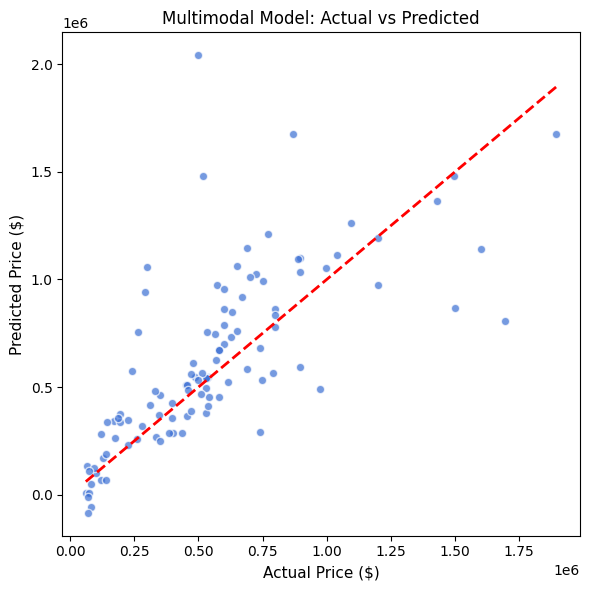

In [10]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, tabular, targets in test_loader:
        images, tabular = images.to(device), tabular.to(device)
        outputs = model(images, tabular).cpu().numpy()

        all_preds.extend(outputs)
        all_targets.extend(targets.numpy())

# Inverse transform to get real dollar values
preds_inv = price_scaler.inverse_transform(np.array(all_preds).reshape(-1, 1)).flatten()
targets_inv = price_scaler.inverse_transform(np.array(all_targets).reshape(-1, 1)).flatten()

mae = mean_absolute_error(targets_inv, preds_inv)
rmse = np.sqrt(mean_squared_error(targets_inv, preds_inv))

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

# ── Plot ─────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(targets_inv, preds_inv, alpha=0.7, edgecolors='white', color='#3b6fd4')
plt.plot([targets_inv.min(), targets_inv.max()],
         [targets_inv.min(), targets_inv.max()],
         'r--', lw=2)
plt.xlabel('Actual Price ($)', fontsize=11)
plt.ylabel('Predicted Price ($)', fontsize=11)
plt.title('Multimodal Model: Actual vs Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('multimodal_results.png', dpi=150)
plt.show()

In [11]:
!pip install gradio -q


In [ ]:
import gradio as gr
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as transforms

# ── Reuse objects already in memory from previous cells ──────────────
# model, price_scaler, tabular_transform, device

# ── Inference transform (same as training) ───────────────────────────
infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Unique sorted zipcodes seen during training ───────────────────────
known_zipcodes = sorted(df['zipcode'].unique().tolist())


# ════════════════════════════════════════════════════════════════════
#  PREDICTION FUNCTION
# ════════════════════════════════════════════════════════════════════
def predict_price(image, bedrooms, bathrooms, area, zipcode):
    """
    Parameters
    ----------
    image      : PIL.Image  – uploaded house photo
    bedrooms   : int
    bathrooms  : int
    area       : float      – square footage
    zipcode    : str        – selected from dropdown

    Returns
    -------
    str  – formatted price prediction + feature summary
    """

    # ── 1. Validate inputs ────────────────────────────────────────────
    if image is None:
        return "Upload a house image.", "", ""

    errors = []
    if bedrooms < 1:
        errors.append("Bedrooms must be ≥ 1")
    if bathrooms < 1:
        errors.append("Bathrooms must be ≥ 1")
    if area <= 0:
        errors.append("Area must be > 0 sq ft")
    if errors:
        return "  " + " | ".join(errors), "", ""

    # ── 2. Preprocess image ───────────────────────────────────────────
    img_tensor = infer_transform(image.convert("RGB"))   # [3, 224, 224]
    img_tensor = img_tensor.unsqueeze(0).to(device)      # [1, 3, 224, 224]

    # ── 3. Preprocess tabular ─────────────────────────────────────────
    tab_df = pd.DataFrame([[bedrooms, bathrooms, area, int(zipcode)]],
                          columns=['bedrooms', 'bathrooms', 'area', 'zipcode'])

    tab_array = tabular_transform.transform(tab_df).astype(np.float32)
    tab_tensor = torch.tensor(tab_array).to(device)      # [1, feature_dim]

    # ── 4. Model inference ────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        scaled_pred = model(img_tensor, tab_tensor).cpu().numpy()

    # ── 5. Inverse-transform prediction ──────────────────────────────
    real_price = price_scaler.inverse_transform(
        scaled_pred.reshape(-1, 1)
    ).flatten()[0]

    # ── 6. Build output strings ───────────────────────────────────────
    price_str = f"Estimated Price:  **${real_price:,.0f}**"

    summary = (
        f"**Bedrooms:** {bedrooms}   |   "
        f"**Bathrooms:** {bathrooms}   |   "
        f"**Area:** {area:,.0f} sq ft   |   "
        f"**Zipcode:** {zipcode}"
    )

    # Simple confidence band (±10 % heuristic)
    lo, hi = real_price * 0.90, real_price * 1.10
    band = f"Estimated range:  ${lo:,.0f}  –  ${hi:,.0f}"

    return price_str, summary, band


# ════════════════════════════════════════════════════════════════════
#  GRADIO LAYOUT
# ════════════════════════════════════════════════════════════════════
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="🏠 Multimodal House Price Predictor"
) as demo:

    # ── Header ────────────────────────────────────────────────────────
    gr.Markdown(
        """
        #  Multimodal House Price Predictor
        Upload a **frontal house photo** and fill in the property details.
        The model fuses **ResNet18 image features** with **tabular data** to estimate the price.
        """
    )

    # ── Main layout: inputs left | outputs right ──────────────────────
    with gr.Row():

        # LEFT COLUMN – inputs
        with gr.Column(scale=1):
            gr.Markdown("### House Image")
            image_input = gr.Image(
                type="pil",
                label="Upload frontal photo",
                height=260
            )

            gr.Markdown("### Property Details")
            bedrooms_input = gr.Slider(
                minimum=1, maximum=10, step=1, value=3,
                label="Bedrooms"
            )
            bathrooms_input = gr.Slider(
                minimum=1, maximum=8, step=1, value=2,
                label="Bathrooms"
            )
            area_input = gr.Number(
                value=1800,
                label="Living Area (sq ft)",
                precision=0
            )
            zipcode_input = gr.Dropdown(
                choices=[str(z) for z in known_zipcodes],
                value=str(known_zipcodes[0]),
                label="Zipcode"
            )

            predict_btn = gr.Button(
                "Predict Price",
                variant="primary",
                size="lg"
            )

        # RIGHT COLUMN – outputs
        with gr.Column(scale=1):
            gr.Markdown("###Prediction")
            price_output = gr.Markdown(
                value="_Upload an image and click **Predict Price**_"
            )

            gr.Markdown("### Input Summary")
            summary_output = gr.Markdown()

            gr.Markdown("### Confidence Band  *(±10 % heuristic)*")
            band_output = gr.Markdown()

            gr.Markdown("---")

            # Show a sample from the test set for quick demo
            gr.Markdown("### 🖼️ Sample Test Images")
            sample_gallery = gr.Gallery(
                value=[df.iloc[i]['image_path'] for i in test_idx[:6]],
                label="Click any image, then drag it to the upload box",
                columns=3,
                height=200
            )

    # ── Wire up button ────────────────────────────────────────────────
    predict_btn.click(
        fn=predict_price,
        inputs=[
            image_input,
            bedrooms_input,
            bathrooms_input,
            area_input,
            zipcode_input
        ],
        outputs=[price_output, summary_output, band_output]
    )

    # ── Footer ────────────────────────────────────────────────────────
    gr.Markdown(
        """
        ---
        **Model:** ResNet18 (frozen) + Tabular MLP → Fusion Head
        **Dataset:** [Houses Dataset](https://github.com/emanhamed/Houses-dataset)
        **Metrics on test set:** reported in Cell 8
        """
    )

demo.launch(share=True, debug=True)   # share=True gives a public Colab URL

/tmp/ipykernel_6295/922949366.py:95: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://58b3643832fb5781a8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
